# GPT-2 with PyTorch

In this notebook, we will continue to examine the GPT architecture - a neural network that is used in many popular Large Language Models (LLMs).

**Learning Objectives**

1. Construct a transformer block to utilize in an LLM architecture
2. Organize the components of an LLM for text prediction
3. Load pre-trained weights into the layers of an LLM architecture

**Import modules**

Begin by importing the modules to be used in this notebook

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from IPython.display import Image as IPI

In [7]:
from gpt2_helper_functions import MultiHeadAttention, load_gpt2_params_from_tf_ckpt
from gpt2_helper_functions import load_weights, gpt_tokenizer  

In [8]:
import tensorflow as tf
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch

In [9]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


## The LLM Architecture Revisited

In our previous notebooks on LLM components, we examined the following architecture of a relatively "simple" LLM:

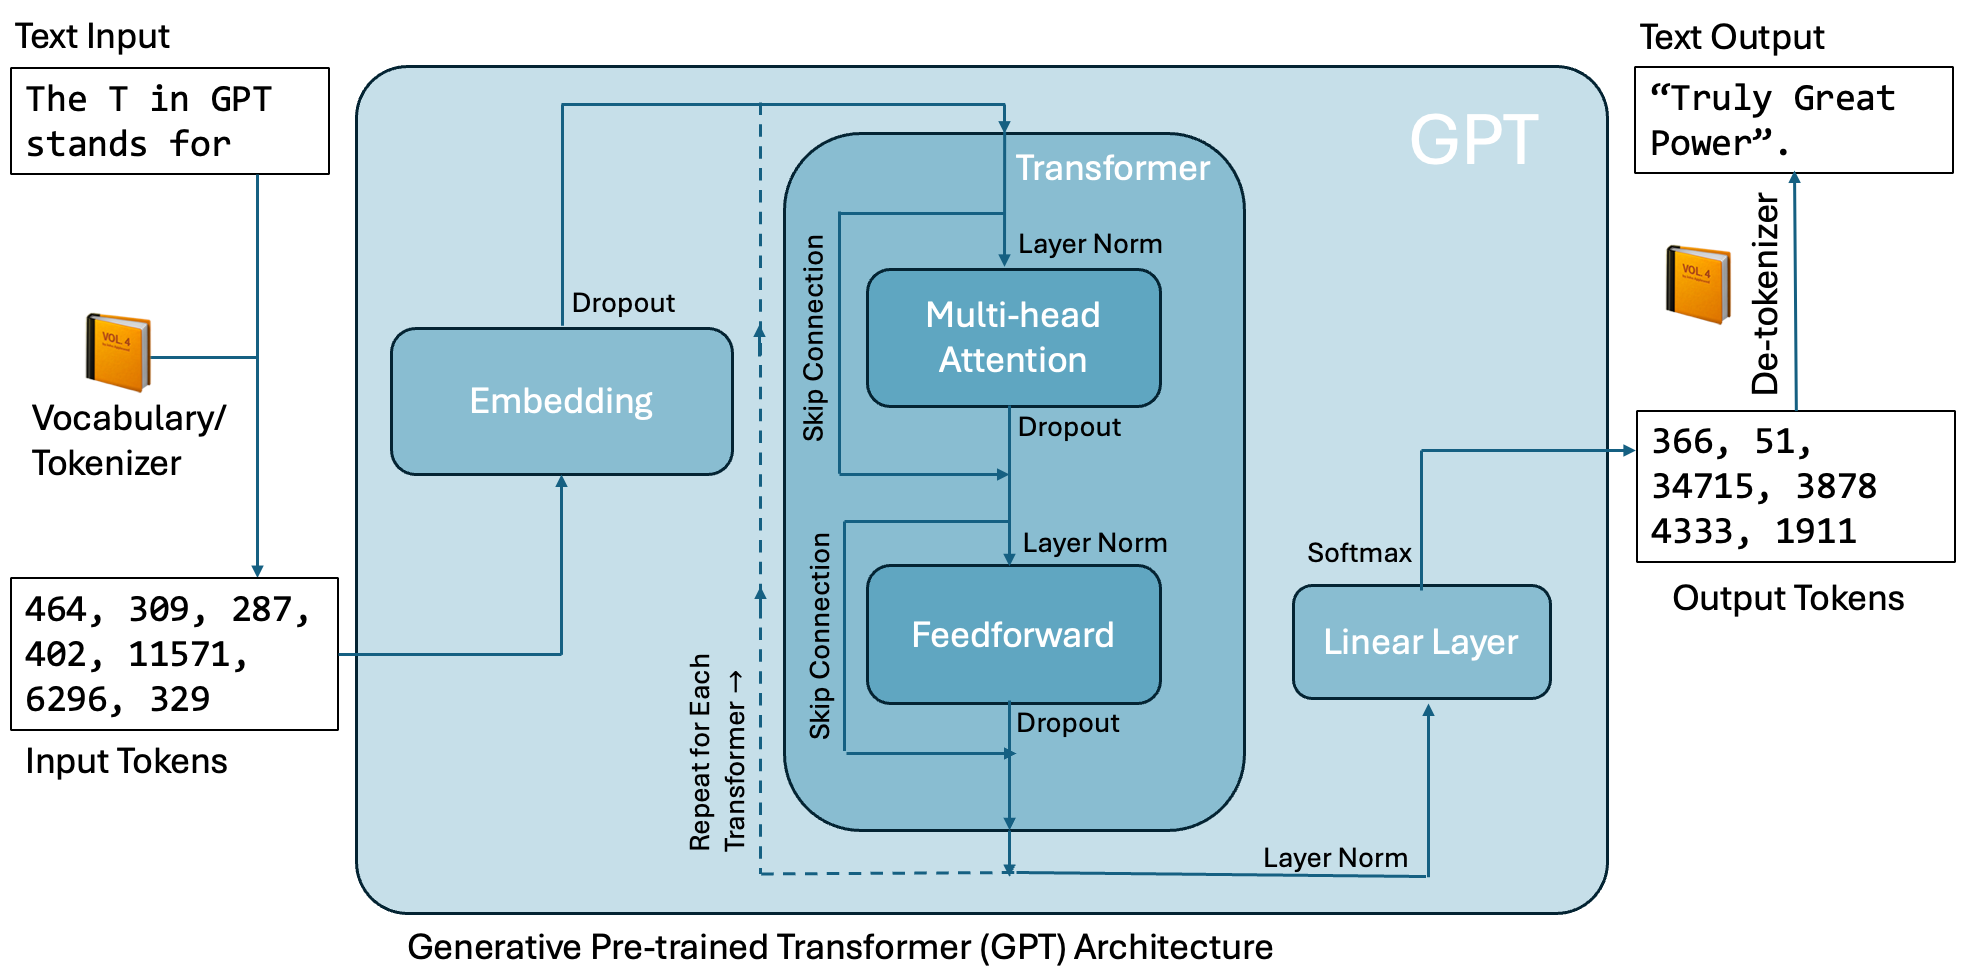

In [10]:
display(IPI(filename=os.path.join('..','images', 'GPT_Schematic.png'), width=500))

In the second-to-last notebook, we saw that text is *tokenized* into integers and these integers are passed into the LLM. Let's load in the tokenizer for the GPT-2 model which we will recreate in this notebook:

In [11]:
gpt2_tokenizer = gpt_tokenizer("gpt2")

Continuing forward, we saw that these tokens are *embedded* into continuous vectors in the first step of the LLM. Then, the embedded vector is passed through a series of Transformer blocks. In the previous notebook, we discussed the concept of *attention*. Here, we will finish coding up the Transformer block and then put all of the pieces together to utilize this "small" LLM example model.

## Transformers

The transformer block is at the heart of the LLM - it uses the attention mechanism along with a linear layer. Let's work to complete a few additional pieces for our Transformer and then put everything together.

#### Layer Normalization
Before each component of the transformer, we will apply normalization to the embeddings. We can code this up into an `nn.Module` class as follows:

In [12]:
class LayerNorm(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(embedding_dim))
        self.shift = nn.Parameter(torch.zeros(embedding_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x-mean) / torch.sqrt(var+self.eps)
        return(self.scale * norm_x + self.shift)

Looking at the forward method of this class, we can see the familiar normalization procedure we've seen in other contexts in this course.

#### Yet Another Activation Function

One final piece we will implement in our transformer is an activation function for our linear layers. We could use one of the previous activations we've seen before, but since we're going to replicate the GPT-2 model, we'll need the exact activation function of that architecture. Here, we will use the *Gaussian Error Linear Unit* which is a smooth version of ReLU. It can be approximated as follows:

In [13]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return( 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) \
            * (x+0.044715 * torch.pow(x, 3))
        )))

We can verify that this activation is very similar to ReLU by plotting them on the same plot:

In [14]:
# make a vector to sample the activation functions
x = torch.arange(-3,2,0.01)

# compute the ReLU values
R = nn.ReLU()
y_RELU = R(x)

# compute the GELU values
G = GELU()
y_GELU = G(x)

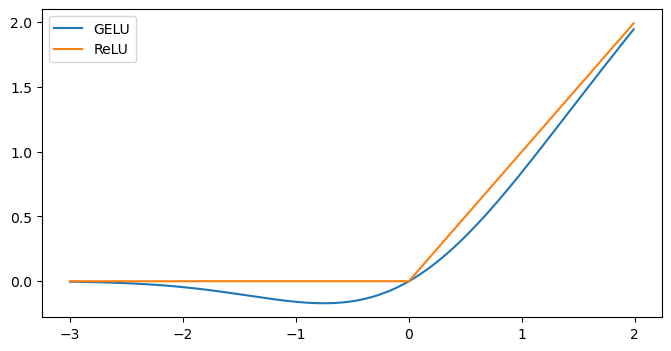

In [15]:
# make a plot of the two activation functions
plt.figure(figsize=(8,4))
plt.plot(x,y_GELU, label='GELU')
plt.plot(x,y_RELU, label='ReLU')
plt.legend()
plt.show()

#### Coding up the Transformer Block
With all these pieces in hand, we're ready to start coding up our Transformer!

Let's do that here:

In [16]:
class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # implement an attention cell using the 
        # MultiHeadAttention function from the previous notebook
        self.attention = MultiHeadAttention(
            d_in = config['embedding_dim'],
            d_out = config['embedding_dim'],
            context_length = config['context_length'],
            num_heads = config['n_heads'],
            dropout = config['dropout_rate'],
            qkv_bias = config['qkv_bias'])

        # implement a small feed-forward layer
        self.feedforward = nn.Sequential(
            nn.Linear(config['embedding_dim'], 4*config['embedding_dim']),
            GELU(),
            nn.Linear(4*config['embedding_dim'], config['embedding_dim']))

        # add two normalization layers and a dropout layer
        self.norm1 = LayerNorm(config['embedding_dim'])
        self.norm2 = LayerNorm(config['embedding_dim'])
        self.dropout = nn.Dropout(config['dropout_rate'])

    def forward(self, x):

        # implement the forward method
        shortcut = x
        x = self.norm1(x)
        x = self.attention(x)
        x = self.dropout(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.feedforward(x)
        x = self.dropout(x)
        x = x + shortcut

        return(x)

As we can see, this Transformer block uses many of the tools we've already seen via other notebooks and applications in this class.

## Coding Up GPT-2 Small

In the next cells, we're going to code up a `GPTModel` class that replicates GPT-2. However, we'd like this class to be flexible for different sizes of GPT architectures, so we'll base this around a set of configuration parameters in the form of a dictionary.

For GPT-2 Small, the following values describe the architecture:

In [17]:
gpt2_small_config = {
    'vocabulary_size': 50257,
    'context_length': 1024,
    'embedding_dim': 768,
    'n_heads': 12,
    'n_layers': 12,
    'dropout_rate': 0.1,
    'qkv_bias': False
}

With this in hand, we're ready to code up our model! To help guide our coding, let's put the architecture diagram close by so we can reference it as we code:

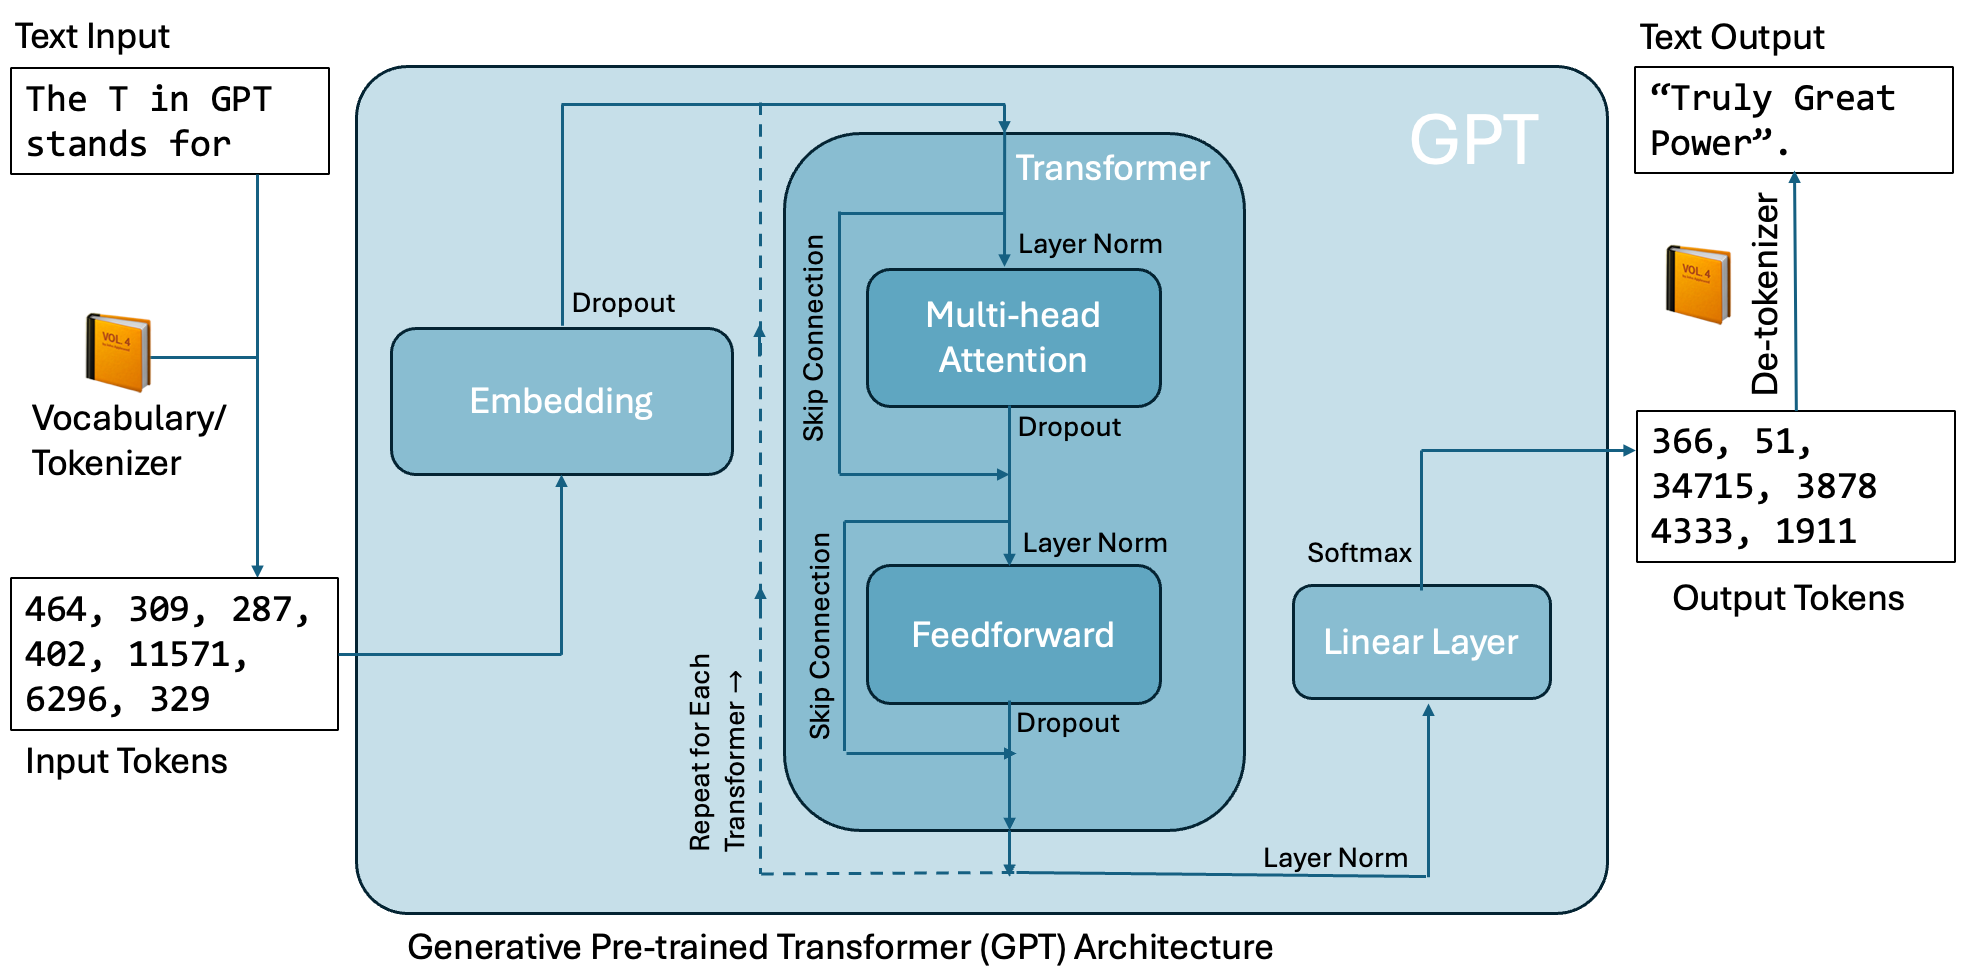

In [18]:
display(IPI(filename=os.path.join('..','images', 'GPT_Schematic.png'), width=500))

In [19]:
class GPTModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        # add the embedding layers
        self.token_embedding = nn.Embedding(config['vocabulary_size'], config['embedding_dim'])
        self.position_embedding = nn.Embedding(config['context_length'], config['embedding_dim'])
        self.dropout_embedding = nn.Dropout(config['dropout_rate'])

        # add the transformer layers
        blocks = []
        for layer in range(config['n_layers']):
            blocks.append(TransformerBlock(config))
        self.transformer_blocks = nn.Sequential(*blocks)

        # create a linear output layer
        self.final_norm = LayerNorm(config['embedding_dim'])
        self.out = nn.Linear(config['embedding_dim'], config['vocabulary_size'], bias=False)

    def forward(self, in_idx):
        batch_size, sequence_len = in_idx.shape

        # first the embeddings
        token_embeddings = self.token_embedding(in_idx)
        position_embeddings = self.position_embedding(
            torch.arange(sequence_len, device = in_idx.device))
        x = token_embeddings + position_embeddings
        x = self.dropout_embedding(x)

        # then the transformer blocks
        x = self.transformer_blocks(x)
        
        # then the output layer
        x = self.final_norm(x)
        logits = self.out(x)
        return(logits)

### Generating Text with GPT-2 Small

Now that we've got our model in hand, we're ready to start producing text. Let's make a function to do just that. The following function will package up the code introduced in the previous notebook for generating text:

In [20]:
def generate_text(model, idx, max_new_tokens, context_size):

    # loop through each token
    for i in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        # evaluate the model
        with torch.no_grad():
            logits = model(idx_cond)

        # compute the probabilities and choose the next token
        # as the one with the highest probability
        logits = logits[:, -1, :]
        probabilities = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probabilities, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)

    return(idx)

Let's see how this works in action. First, let's make some tokens to pass into our model based on an incomplete phrase:

In [21]:
encoded_tensor = gpt2_tokenizer('The T in GPT stands for', return_tensors="pt")['input_ids']
print(encoded_tensor)

tensor([[  464,   309,   287,   402, 11571,  6296,   329]])


Next, let's create a model object with our GPT-2 Small configuration:

In [22]:
gpt2small = GPTModel(gpt2_small_config)

Finally, let's use our text generation function to evaluate the model

In [23]:
gpt2small.eval()
out = generate_text(model=gpt2small,
                           idx=encoded_tensor,
                           max_new_tokens=6,
                           context_size=gpt2_small_config['context_length'])
print(out)

tensor([[  464,   309,   287,   402, 11571,  6296,   329, 28943, 19729, 17392,
         31358, 44599, 13885]])


Of course, the model has given us tokens, but we need to convert these back to words with our token dictionary. Let's do that here:

In [24]:
decoded_text = gpt2_tokenizer.decode(out[0])
print(decoded_text)

The T in GPT stands for resistingmonton importedberra Nou approaching


Shoot... our model is producing nonsense. Well, we've set up our model but we have not trained our model on any actual data. Thus, the model will give us answers, but only because all of the weight parameters were initialized with random values. We could consider training this model, but on our laptops it would take an extraordinary amount of time (and training data) to do so. To get around this problem, we'll rely on pre-trained weights for this model. These weights were obtained by training this model using a huge array of computational resource - more than we have on our laptops.

### Loading Pre-trained Weights

The pre-trained weights for this model are available publicly and can be accessed on Kaggle [HERE](https://www.kaggle.com/datasets/xhlulu/openai-gpt2-weights).

Since the initial model was written and constructed using `TensorFlow`, we'll need to use some of the tools from this package to interpret the data structure - don't worry, we will link these into our PyTorch model once we have them read in.

First, we read in the settings for the model, which should look strikingly familiar to our configuration dictionary above:

In [25]:
# define the data directory
data_dir = os.path.join('..','data','LLMs')

# read in the settings
settings = json.load(open(os.path.join(data_dir,"hparams.json"), "r", encoding="utf-8"))
print(settings)

{'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


Then, we'll use a function provided with this notebook to read in the model parameters:

In [26]:
tf_ckpt_path = tf.train.latest_checkpoint(data_dir)
params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

This params object is huge dictionary of weight parameters that will allow us to link the weights to their associated layer in the GPT-2 Small architecture. We can accomplish this with the following call:

In [27]:
load_weights(gpt2small, params)

Take a look at this function in the provided set of code for this notebook. There, we'll see that each individual layer of our GPT-2 Small model is assigned a set of weights from the dictionary.

Now that the pre-trained weights are loaded in, we can revisit our text generation:

In [28]:
gpt2small.eval()
out = generate_text(model=gpt2small,
                           idx=encoded_tensor,
                           max_new_tokens=6,
                           context_size=gpt2_small_config['context_length'])
decoded_text = gpt2_tokenizer.decode(out[0])
print(decoded_text)

The T in GPT stands for "Truly Great Power".


As we can see, we now retrieve some coherent text from our model in contrast to the nonsense text we generated with our untrained weights. 

From here, we have many options for our model that we could use in real-world scenarios including fine-tuning the model for specific tasks such as classification or responding to inquiries. I'll leave this to you for your own exploration.

**Key Takeaways**

1. While LLMs are "large" in the sense that they have many millions of parameters, the functional components can be constructed and run on a laptop.
2. Training an LLM requires a lot of computational resources; using pre-trained weights allows us to test and work with LLMs on our own machines without the need for huge arrays of GPUs at our disposal.